In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.chdir(r"C:\Users\hp\bluestock_mf_capstone\data\processed")

print("Current Directory:", os.getcwd())

Current Directory: C:\Users\hp\bluestock_mf_capstone\data\processed


In [3]:
nav_history = pd.read_csv(
    "nav_history_clean.csv"
)

investor_transactions = pd.read_csv(
   "investor_transactions_clean.csv"
)

In [4]:
os.chdir(r"C:\Users\hp\bluestock_mf_capstone\data\raw")

In [5]:
fund_master = pd.read_csv(
    "01_fund_master.csv"
)

portfolio_holdings = pd.read_csv(
    "09_portfolio_holdings.csv"
)

## Historical VaR (95%) & CVaR

In [6]:
nav_history['date'] = pd.to_datetime(
    nav_history['date']
)

nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

In [7]:
nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

In [8]:
## Computing VaR and CVaR:
risk_results = []

for fund in nav_history['amfi_code'].unique():

    returns = nav_history[
        nav_history['amfi_code'] == fund
    ]['daily_return'].dropna()

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    risk_results.append([
        fund,
        var_95,
        cvar_95
    ])

In [9]:
var_cvar_report = pd.DataFrame(
    risk_results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
## Sorting worst risk first
var_cvar_report = (
    var_cvar_report
    .sort_values(
        'VaR_95'
    )
)

var_cvar_report.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [11]:
var_cvar_report.to_csv(
    r"C:\Users\hp\bluestock_mf_capstone\reports\var_cvar_report.csv",
    index=False
)

In [12]:
var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [13]:
## Rolling 90-Day Sharpe Ratio

In [14]:
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

In [15]:
rolling_sharpe_df = pd.DataFrame()

for fund in key_funds:

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe_df = pd.concat(
        [rolling_sharpe_df, temp]
    )

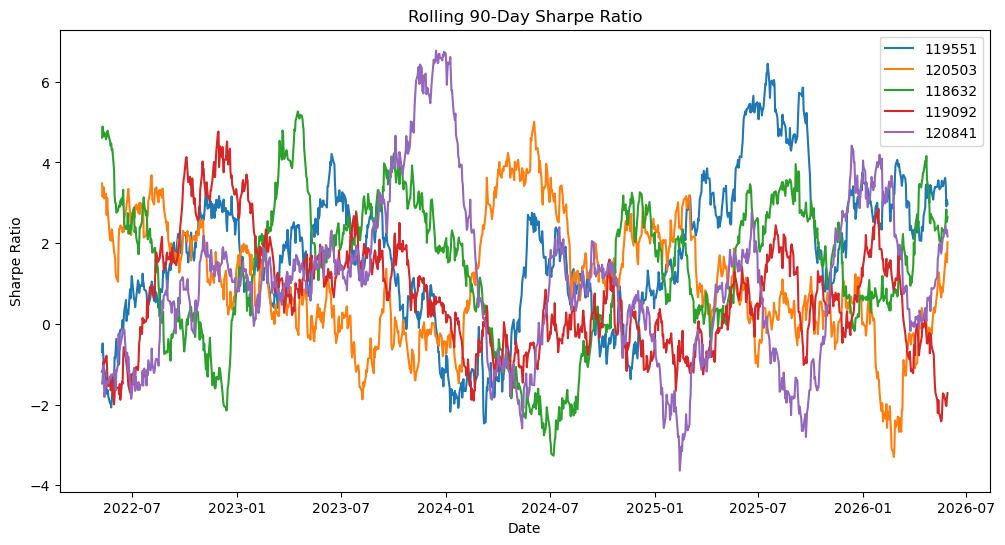

In [16]:
plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.show()

## Investor Cohort Analysis

In [17]:
investor_transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [18]:
## Investor Cohort Analysis
## Convert Date
investor_transactions['transaction_date'] = pd.to_datetime(
    investor_transactions['transaction_date']
)

In [19]:
## Find First Transaction Year
first_txn = (
    investor_transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

In [20]:
## Attach Cohort Year
investor_transactions = pd.merge(
    investor_transactions,
    first_txn[
        ['investor_id','cohort_year']
    ],
    on='investor_id',
    how='left'
)

In [21]:
## Cohort Summary

## Average SIP amount and Total Invested

cohort_summary = (
    investor_transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount = (
            'amount_inr',
            'mean'
        ),
        total_invested = (
            'amount_inr',
            'sum'
        ),
        investor_count = (
            'investor_id',
            'nunique'
        )
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [22]:
## Top Fund Preference
## Finding the most frequently invested fund for each cohort.

top_funds = (
    investor_transactions
    .groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(
        name='transaction_count'
    )
)

In [23]:
top_funds = (
    top_funds
    .sort_values(
        ['cohort_year',
         'transaction_count'],
        ascending=[True,False]
    )
)

In [24]:
top_fund_preference = (
    top_funds
    .groupby('cohort_year')
    .first()
    .reset_index()
)

top_fund_preference

,cohort_year,amfi_code,transaction_count
0,2024,148568,874
1,2025,119599,12


In [25]:
cohort_analysis = pd.merge(
    cohort_summary,
    top_fund_preference[
        ['cohort_year','amfi_code']
    ],
    on='cohort_year'
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investor_count,amfi_code
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


## SIP Continuity Analysis

In [26]:
# Keeping Only SIP Transactions
sip_txns = investor_transactions[
    investor_transactions['transaction_type']
    == 'SIP'
].copy()

In [27]:
sip_txns = sip_txns.sort_values(
    ['investor_id','transaction_date']
)

In [28]:
# Calculating Gap Between Transactions
sip_txns['gap_days'] = (
    sip_txns.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [29]:
## Keeping Investors with 6+ SIP Transactions
sip_counts = (
    sip_txns.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible_investors = sip_counts[
    sip_counts['sip_count'] >= 6
]['investor_id']

In [30]:
## Filtering Eligible Investors
sip_txns = sip_txns[
    sip_txns['investor_id']
    .isin(eligible_investors)
]

In [31]:
## Average Gap
sip_continuity = (
    sip_txns
    .groupby('investor_id')
    .agg(
        avg_gap_days=(
            'gap_days',
            'mean'
        )
    )
    .reset_index()
)

In [32]:
# Risk Flag
sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Active'
)

In [33]:
sip_continuity['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

## Simple Fund Recommender

In [34]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [35]:
rf = 0.065

sharpe_results = []

for fund in nav_history['amfi_code'].unique():

    returns = nav_history[
        nav_history['amfi_code'] == fund
    ]['daily_return'].dropna()

    annual_return = returns.mean() * 252

    annual_vol = returns.std() * np.sqrt(252)

    sharpe_ratio = (
        (annual_return - rf)
        / annual_vol
    )

    sharpe_results.append(
        [fund, sharpe_ratio]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [36]:
## Merging Sharpe with Fund Master
recommender_df = pd.merge(
    sharpe_df,
    fund_master[
        ['amfi_code',
         'scheme_name',
         'risk_category']
    ],
    on='amfi_code',
    how='left'
)

recommender_df.head()

,amfi_code,sharpe_ratio,scheme_name,risk_category
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,Moderate
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,Low
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,Moderate
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth,Very High


In [37]:
## Checking Risk Categories
recommender_df['risk_category'].value_counts()

risk_category
Moderate           16
High                8
Low                 6
Very High           6
Moderately High     4
Name: count, dtype: int64

In [38]:
## Creating Recommender Function
def recommend_funds(risk_appetite):

    recommendations = (
        recommender_df[
            recommender_df['risk_category']
            == risk_appetite
        ]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            'scheme_name',
            'risk_category',
            'sharpe_ratio'
        ]
    ]

In [39]:
recommend_funds("Low")

,scheme_name,risk_category,sharpe_ratio
27,ICICI Pru Liquid Fund - Regular - Growth,Low,0.495723
31,Kotak Liquid Fund - Regular - Growth,Low,-0.088747
18,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.226575


In [40]:
recommend_funds("Moderate")

,scheme_name,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448291
19,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208267
9,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.081659


In [41]:
recommend_funds("High")

,scheme_name,risk_category,sharpe_ratio
36,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.234930
25,ICICI Pru Midcap Fund - Regular - Growth,High,1.180101
38,DSP Midcap Fund - Regular - Growth,High,1.132122


In [42]:
recommend_funds("Very High")

,scheme_name,risk_category,sharpe_ratio
39,DSP Small Cap Fund - Regular - Growth,Very High,0.949796
21,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.945308
11,Nippon India Small Cap Fund - Regular - Growth,Very High,0.448434


In [44]:
recommend_funds("Moderately High")

,scheme_name,risk_category,sharpe_ratio
30,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.306744
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,0.926287
26,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.648879


## Sector HHI Concentration Analysis

In [45]:
portfolio_holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [46]:
## Converting Weights to Decimals
portfolio_holdings['weight_decimal'] = (
    portfolio_holdings['weight_pct'] / 100
)

In [52]:
## Calculating HHI
hhi_df = (
    portfolio_holdings
    .groupby('amfi_code')['weight_decimal']
    .apply(
        lambda x: (x ** 2).sum()
    )
    .reset_index(name='HHI')
)

In [53]:
## Rank Funds
hhi_df = hhi_df.sort_values(
    'HHI',
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [54]:
## Creating Category
hhi_df['concentration_level'] = np.where(
    hhi_df['HHI'] > 0.25,
    'High',
    np.where(
        hhi_df['HHI'] > 0.15,
        'Moderate',
        'Low'
    )
)

In [55]:
hhi_df.head()

,amfi_code,HHI,concentration_level
11,119092,0.206448,Moderate
3,101207,0.200700,Moderate
18,119599,0.174751,Moderate
4,102885,0.174709,Moderate
7,118632,0.168298,Moderate


In [56]:
hhi_df['concentration_level'].value_counts()

concentration_level
Low         25
Moderate     9
Name: count, dtype: int64

## Advanced Insights

### 1. Risk Analysis
Fund 119599 recorded the highest downside risk with a VaR (95%) of -2.69% and a CVaR of -3.24%, indicating larger losses during adverse market conditions compared to other funds.

### 2. Rolling Performance
The Rolling 90-Day Sharpe Ratio analysis showed significant variation in risk-adjusted performance across the selected funds, reflecting changing market conditions and fund management effectiveness over time.

### 3. Investor Cohort Behavior
The 2024 investor cohort contributed the majority of investments, with over 4,800 investors and total investments exceeding ₹349 crore, making it the most significant investor segment in the dataset.

### 4. SIP Continuity
SIP continuity analysis revealed that 1,332 investors were classified as At-Risk due to average transaction gaps exceeding 35 days, while only 30 investors maintained consistent SIP behavior.

### 5. Portfolio Concentration
Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) showed that most funds maintained diversified portfolios. Out of 34 funds analyzed, 25 exhibited low concentration and 9 showed moderate concentration, with no highly concentrated portfolios observed.

In [59]:
import os

os.path.exists("Advanced_Analytics.py")

False

In [60]:

os.getcwd()

'C:\\Users\\hp\\bluestock_mf_capstone\\data\\raw'

In [61]:
print(os.listdir())

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'bluestock_mf.db']
